In [1]:

import numpy as np
# to read .nc files
import xarray as xr

import tensorflow as tf

import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

# Training callbacks:
# These help us save the best model, stop unnecessary training,
# and reduce the learning rate when training stops improving.
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)



TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
#  final spatial grid  1° × 1°.

#  number of latitdude points
LAT_SIZE = 180

# Number of longitude points.
LON_SIZE = 360


# Number of environmental variables given to the model.

# 1 → SST
# 2 → SSH
# 3 → U10
# 4 → V10

# Therefore:
# N_FEATURES = 4
N_FEATURES = 4


# Number of previous time steps given to ConvLSTM.
#
# For example:
#
# Month 1
# Month 2
# Month 3
#    ↓
# Model prediction
#
TIME_STEPS = 3


#  predict temprature corresponding to their depth
DEPTHS = np.array([
    30,
    50,
    75,
    100,
    125,
    150,
    200,
    250,
    300,
    400,
    500,
    600,
    700,
    800,
    900,
    1000,
    1100,
    1200,
    1300,
    1400,
    1500,
    1750,
    2000
])


# Number of output depth levels.
N_DEPTHS = len(DEPTHS)


print("Latitude:", LAT_SIZE)
print("Longitude:", LON_SIZE)
print("Input features:", N_FEATURES)
print("Time steps:", TIME_STEPS)
print("Number of output depths:", N_DEPTHS)
print("Depths:", DEPTHS)

Latitude: 180
Longitude: 360
Input features: 4
Time steps: 3
Number of output depths: 23
Depths: [  30   50   75  100  125  150  200  250  300  400  500  600  700  800
  900 1000 1100 1200 1300 1400 1500 1750 2000]


In [3]:
# Creating the fake data for the architecture testing of model

X_test = np.random.randn(
    1,                  # Number of samples
    TIME_STEPS,         # 3 time steps
    LAT_SIZE,           # 180 latitude
    LON_SIZE,            # 360 longitude
    N_FEATURES           # 4 variables
).astype(np.float32)



Y_test = np.random.randn(
    1,                  # Number of samples
    LAT_SIZE,           # 180
    LON_SIZE,            # 360
    N_DEPTHS             # 23 depths
).astype(np.float32)


print("Input shape :", X_test.shape)
print("Target shape:", Y_test.shape)

Input shape : (1, 3, 180, 360, 4)
Target shape: (1, 180, 360, 23)


In [4]:
def build_convlstm_model():

    # model receives these input

    # 3 time steps
    # 180 latitude
    # 360 longitude
    # 4 environmental variables
    inputs = layers.Input(
        shape=(
            TIME_STEPS,
            LAT_SIZE,
            LON_SIZE,
            N_FEATURES
        )
    )

    # FIRST ConvLSTM LAYER

    #
    # ConvLSTM :)  cnn and lstm :

    # filters=8 means we initially learn 8 feature maps.

    x = layers.ConvLSTM2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        activation="tanh"
    )(inputs)


    # Batch normalization:

    # Helps stabilize the activations during training.
    x = layers.BatchNormalization()(x)

    # SECOND ConvLSTM LAYER

    # We increase the number of learned feature maps
    # from 8 → 16.

    x = layers.ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False,
        activation="tanh"
    )(x)


    # Normalize the learned features.
    x = layers.BatchNormalization()(x)


    # SPATIAL FEATURE REFINEMENT

    # Conv2D processes the spatial representation

    x = layers.Conv2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )(x)


    # OUTPUT LAYER

    # We need 23 temperature predictions
    # at every 1° × 1° grid cell.

    # filters = 23

    outputs = layers.Conv2D(
        filters=N_DEPTHS,
        kernel_size=(1, 1),
        padding="same",
        activation="linear"
    )(x)


    # Create the complete model.
    model = models.Model(
        inputs=inputs,
        outputs=outputs
    )


    return model

In [5]:
#our convlstm model
model = build_convlstm_model()

# Display the architecture.
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 180, 360, 4) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 3, 180, 360, 8) │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 180, 360, 8) │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 180, 360, 16)   │        13,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 180, 360, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 360, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 180, 360, 23)   │           391 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,183 (78.84 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 48 (192.00 B)

In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print(tf.config.list_physical_devices())

TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
model.compile(

    # Adam  optimizer responsible for updating neual netwok weights
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    # MSE measures the difference between:
    #
    # predicted temperature ans actual argo temperature

    loss="mse",

    metrics=["mae"]
)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import xarray as xr
# file location
argo_path = "/content/drive/MyDrive/SIH2026/Dataset/ArgoData.nc"


argo = xr.open_dataset(argo_path)

# # display dataset
# print(argo)
argo.head()

<xarray.Dataset> Size: 3kB
Dimensions:    (LEVEL: 5, LATITUDE: 5, LONGITUDE: 5)
Coordinates:
  * LEVEL      (LEVEL) float32 20B 0.0 5.0 10.0 20.0 30.0
  * LATITUDE   (LATITUDE) float32 20B -89.5 -88.5 -87.5 -86.5 -85.5
  * LONGITUDE  (LONGITUDE) float32 20B 0.5 1.5 2.5 3.5 4.5
Data variables:
    TEMP       (LEVEL, LATITUDE, LONGITUDE) float32 500B ...
    SALT       (LEVEL, LATITUDE, LONGITUDE) float32 500B ...
    PTEMP      (LEVEL, LATITUDE, LONGITUDE) float32 500B ...
    PDEN       (LEVEL, LATITUDE, LONGITUDE) float32 500B ...
    ADDEP      (LEVEL, LATITUDE, LONGITUDE) float32 500B ...
    SPICE      (LEVEL, LATITUDE, LONGITUDE) float32 500B ...
Attributes:
    title:    Argo 1x1 degree variationaly interpolated 2020 January mean

In [13]:
# extract the temprature
argo_temp = argo["TEMP"].sel(LEVEL= DEPTHS)
print(argo_temp)
print("Shape",argo_temp.shape)

<xarray.DataArray 'TEMP' (LEVEL: 23, LATITUDE: 180, LONGITUDE: 360)> Size: 6MB
[1490400 values with dtype=float32]
Coordinates:
  * LEVEL      (LEVEL) float32 92B 30.0 50.0 75.0 ... 1.5e+03 1.75e+03 2e+03
  * LATITUDE   (LATITUDE) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * LONGITUDE  (LONGITUDE) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Attributes:
    units:      degC
    title:      Argo Temperature
    long_name:  Argo Temperature
Shape (23, 180, 360)


In [16]:
# currenlty has arrangment depth latitude and longitude and our ml need latitute longitude and depth
#conveting into numpy array
Y_jan = argo_temp.values.astype(np.float32)


# Rearrange dimensions
# Before:
# (depth, latitude, longitude)

# After:
# (latitude, longitude, depth)
Y_jan = np.transpose(
    Y_jan,
    (1, 2, 0)
)


print("Target shape:", Y_jan.shape)

Target shape: (180, 360, 23)


In [17]:


print(
    "NaN percentage:",
    np.isnan(Y_jan).mean() * 100
)


print(
    "Minimum temperature:",
    np.nanmin(Y_jan)
)


print(
    "Maximum temperature:",
    np.nanmax(Y_jan)
)


print(
    "Mean temperature:",
    np.nanmean(Y_jan)
)

NaN percentage: 54.61882716049383
Minimum temperature: -2.049
Maximum temperature: 30.279
Mean temperature: 8.336209


Dataset loaded successfully.
Temperature dimensions: ('LEVEL', 'LATITUDE', 'LONGITUDE')
Temperature shape: (23, 180, 360)

========== BASIC STATISTICS ==========
Valid values : 676,361
NaN values   : 814,039
NaN %        : 54.62%
Minimum      : -2.049 °C
Maximum      : 30.279 °C
Mean         : 8.336 °C
Median       : 5.432 °C
Std          : 7.049 °C


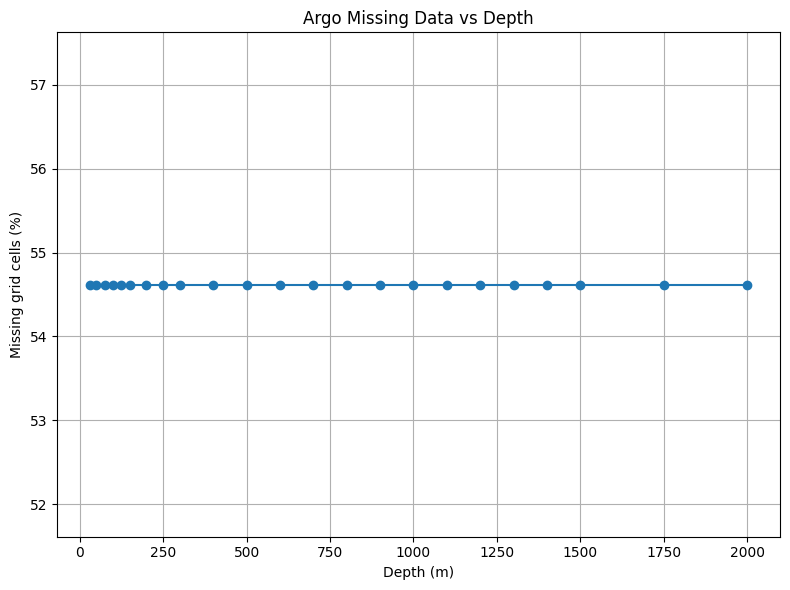

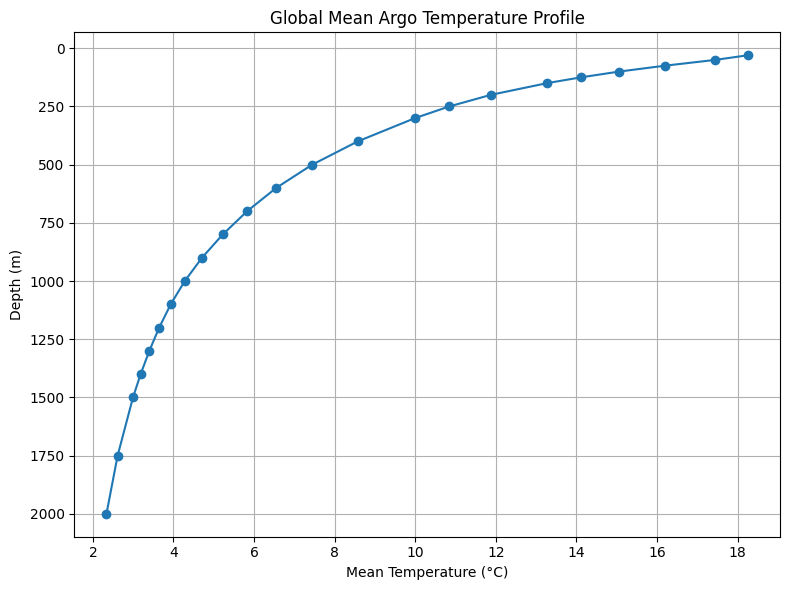

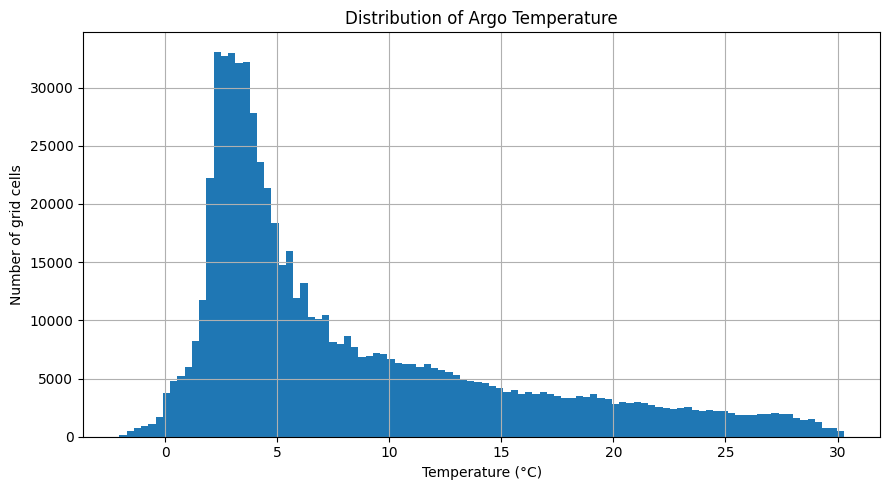

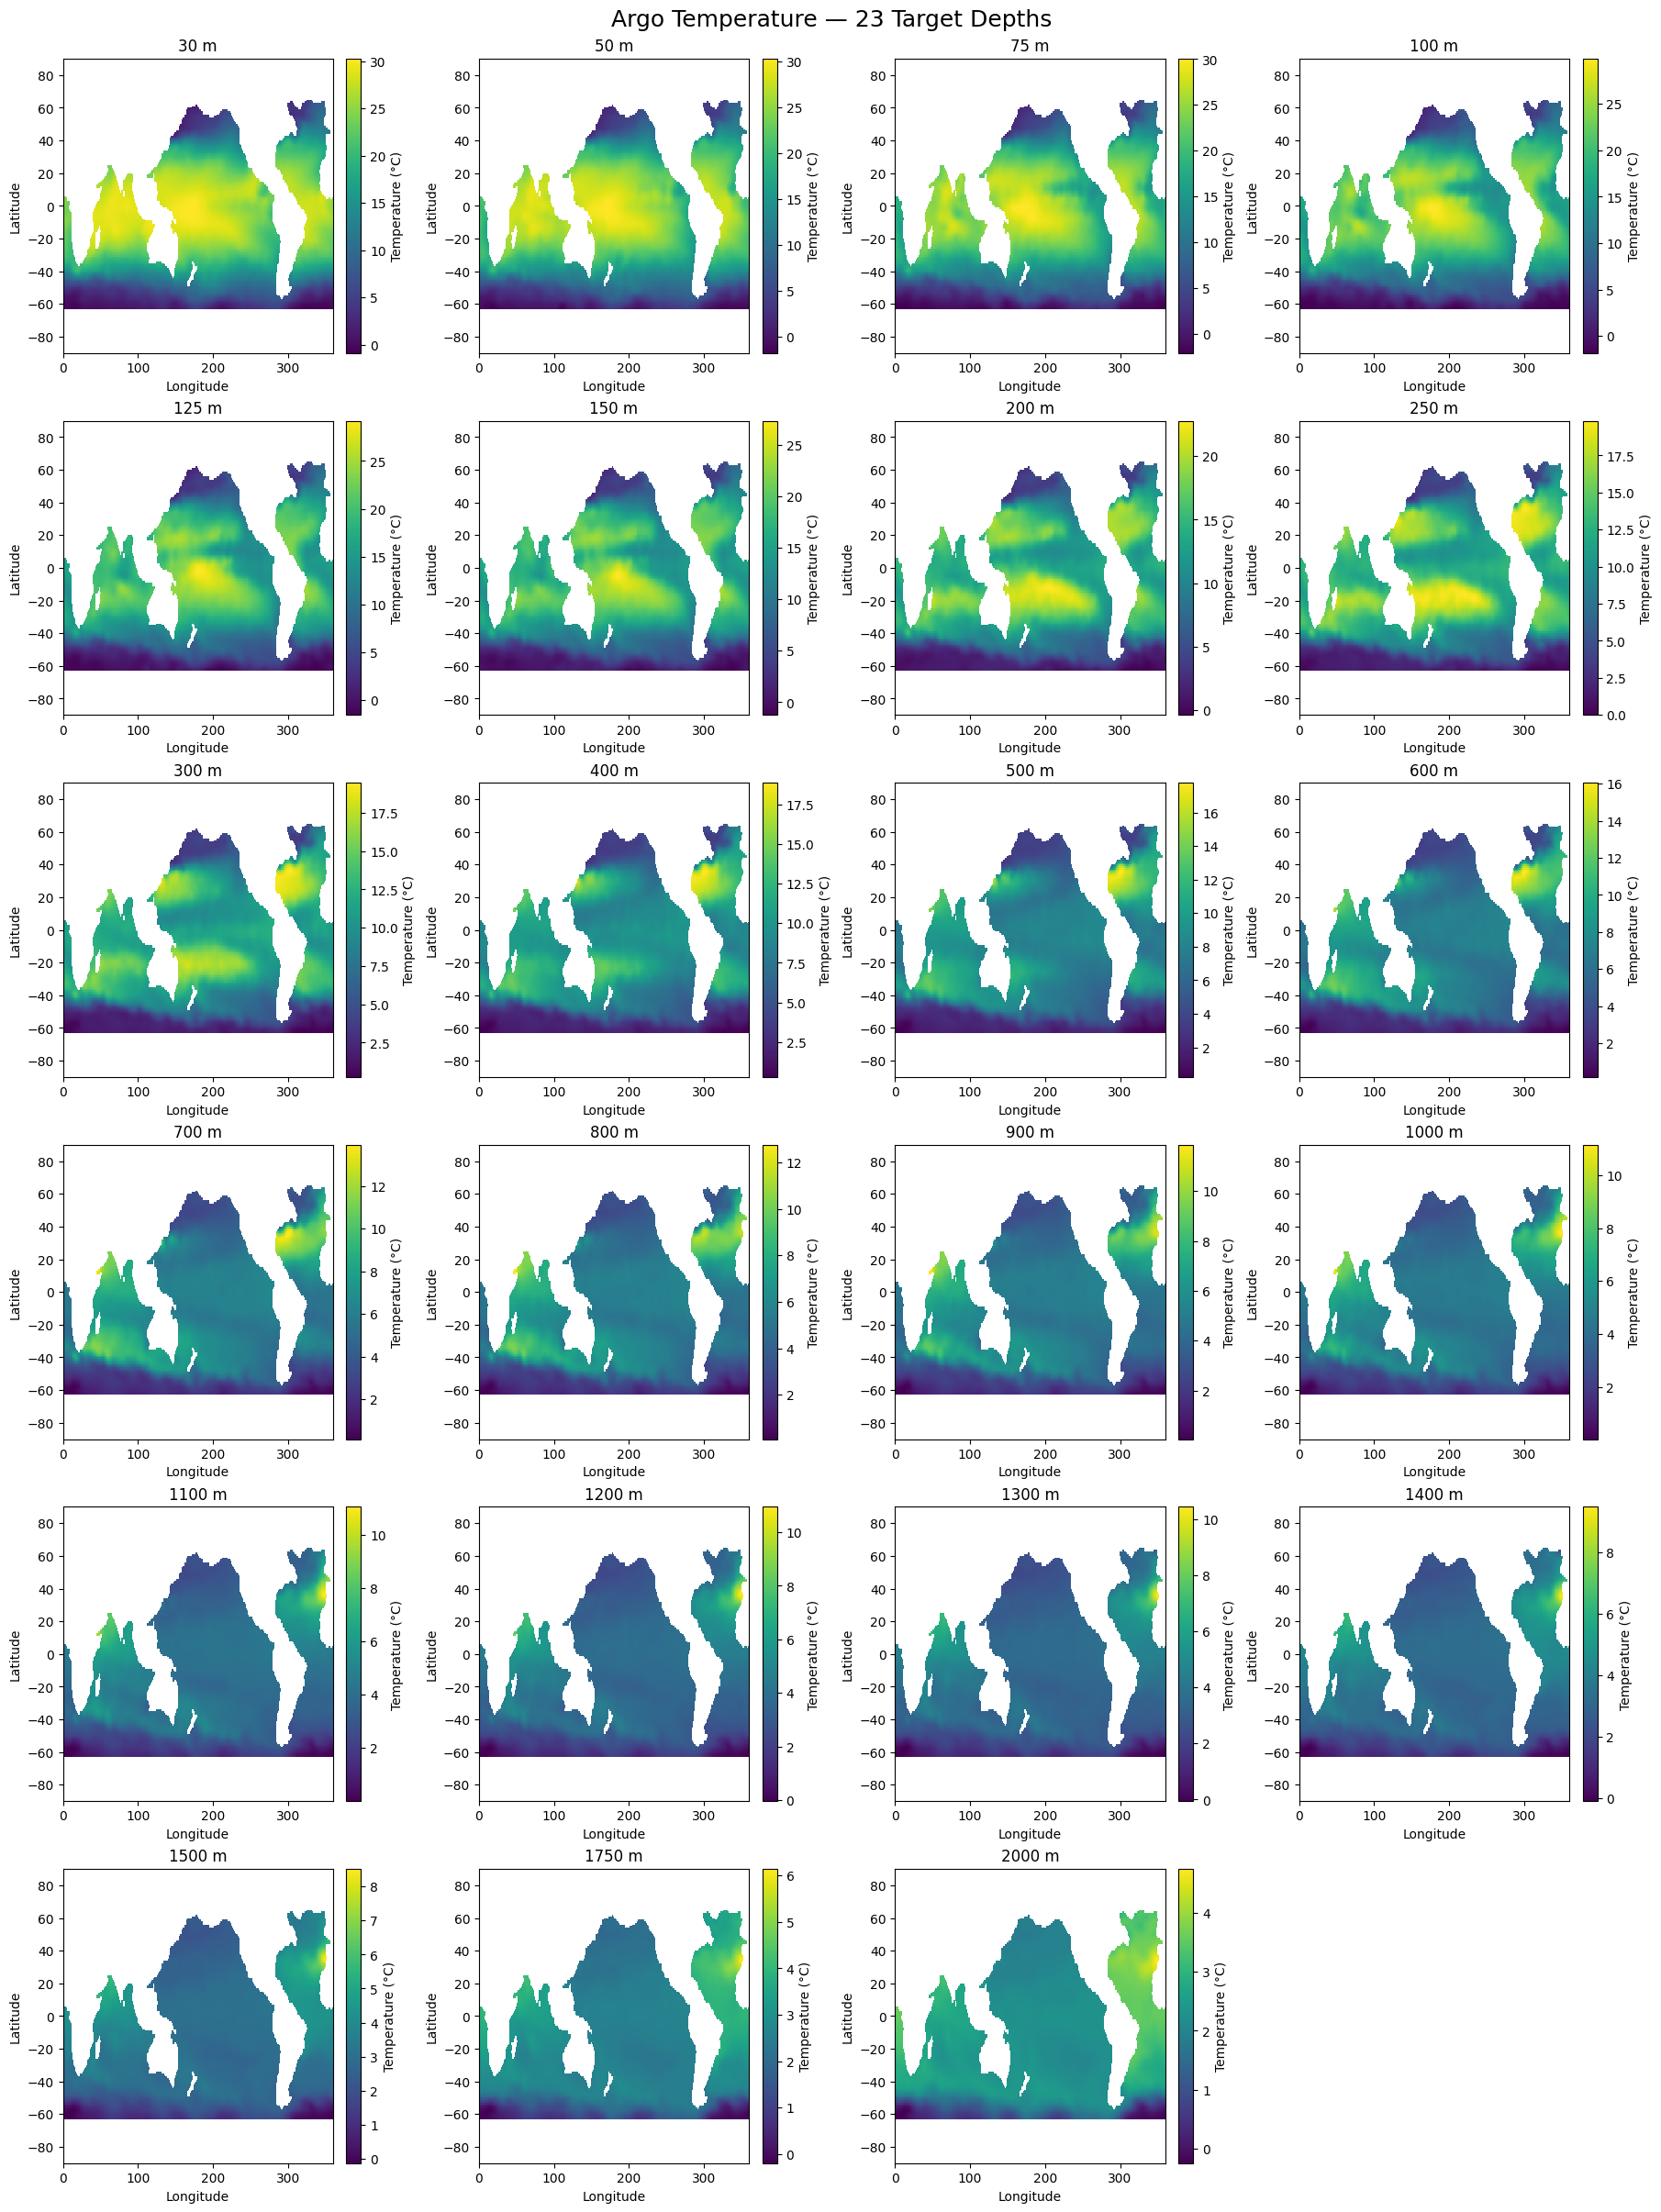

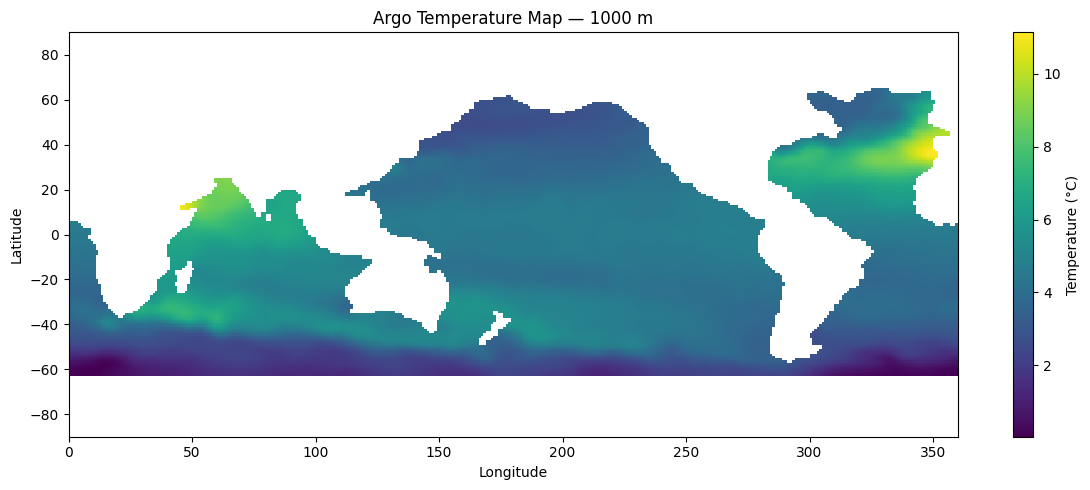

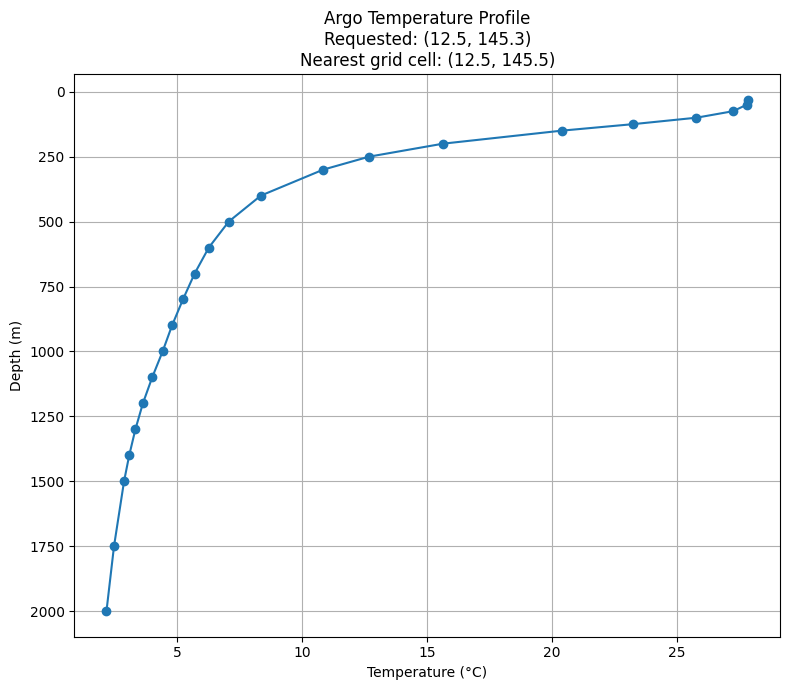


========== DEPTH-WISE ANALYSIS ==========
  30 m | Mean= 18.255 °C | Std=  9.023 °C | Min= -0.877 °C | Max= 30.272 °C | Missing= 54.62%
  50 m | Mean= 17.440 °C | Std=  8.834 °C | Min= -1.772 °C | Max= 30.279 °C | Missing= 54.62%
  75 m | Mean= 16.186 °C | Std=  8.583 °C | Min= -2.049 °C | Max= 30.035 °C | Missing= 54.62%
 100 m | Mean= 15.062 °C | Std=  8.136 °C | Min= -1.819 °C | Max= 29.857 °C | Missing= 54.62%
 125 m | Mean= 14.109 °C | Std=  7.526 °C | Min= -1.546 °C | Max= 29.209 °C | Missing= 54.62%
 150 m | Mean= 13.263 °C | Std=  6.849 °C | Min= -1.238 °C | Max= 27.325 °C | Missing= 54.62%
 200 m | Mean= 11.878 °C | Std=  5.769 °C | Min= -0.373 °C | Max= 22.788 °C | Missing= 54.62%
 250 m | Mean= 10.842 °C | Std=  5.039 °C | Min= -0.003 °C | Max= 19.845 °C | Missing= 54.62%
 300 m | Mean=  9.993 °C | Std=  4.484 °C | Min=  0.258 °C | Max= 19.451 °C | Missing= 54.62%
 400 m | Mean=  8.573 °C | Std=  3.686 °C | Min=  0.287 °C | Max= 18.859 °C | Missing= 54.62%
 500 m | Mean=  7

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ARGO TEMPERATURE EDA / VISUALIZATION
# ============================================================
# Purpose:
# This script performs exploratory data analysis (EDA) on the
# monthly Argo temperature dataset BEFORE ML training.
#
# It creates:
# 1. Missing-data vs depth graph
# 2. Mean temperature vs depth graph
# 3. Temperature histogram
# 4. Maps for all 23 target depths
# 5. A detailed map for one selected depth
# 6. A vertical temperature profile at a requested location
# 7. Depth-wise statistics in the terminal
#
# This script does NOT modify the original NetCDF file.

# 1. FILE PATH
# Put ArgoData.nc in the same directory as this script,
# OR replace this with the full path to your file.
ARGO_PATH =argo_path

# 2. DEPTHS USED BY OUR ML MODEL
DEPTHS = np.array([
    30, 50, 75, 100, 125, 150, 200, 250, 300, 400,
    500, 600, 700, 800, 900, 1000, 1100, 1200, 1300,
    1400, 1500, 1750, 2000
])

# 3. LOAD THE NETCDF DATASET
ds = xr.open_dataset(ARGO_PATH)

# TEMP contains the temperature field:
# (depth, latitude, longitude)
temp = ds["TEMP"].sel(LEVEL=DEPTHS)

print("Dataset loaded successfully.")
print("Temperature dimensions:", temp.dims)
print("Temperature shape:", temp.shape)

# 4. BASIC STATISTICS
# Convert temperature values to NumPy.
values = temp.values

# Keep only valid (non-NaN) temperature values.
valid = values[np.isfinite(values)]

print("\n========== BASIC STATISTICS ==========")
print(f"Valid values : {valid.size:,}")
print(f"NaN values   : {np.isnan(values).sum():,}")
print(f"NaN %        : {np.isnan(values).mean() * 100:.2f}%")
print(f"Minimum      : {np.min(valid):.3f} °C")
print(f"Maximum      : {np.max(valid):.3f} °C")
print(f"Mean         : {np.mean(valid):.3f} °C")
print(f"Median       : {np.median(valid):.3f} °C")
print(f"Std          : {np.std(valid):.3f} °C")

# 5. MISSING DATA VS DEPTH
# Purpose:
# Check whether deeper ocean layers have more missing data.
missing_by_depth = (
    temp.isnull()
        .mean(dim=("LATITUDE", "LONGITUDE")) * 100
)

plt.figure(figsize=(8, 6))
plt.plot(
    DEPTHS,
    missing_by_depth.values,
    marker="o"
)
plt.xlabel("Depth (m)")
plt.ylabel("Missing grid cells (%)")
plt.title("Argo Missing Data vs Depth")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. GLOBAL MEAN TEMPERATURE VS DEPTH
# Purpose:
# Shows the average vertical temperature structure.
mean_profile = temp.mean(
    dim=("LATITUDE", "LONGITUDE"),
    skipna=True
)

plt.figure(figsize=(8, 6))
plt.plot(
    mean_profile.values,
    DEPTHS,
    marker="o"
)
plt.gca().invert_yaxis()
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("Global Mean Argo Temperature Profile")
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. TEMPERATURE DISTRIBUTION
# Purpose:
# Shows the distribution of temperature values and helps
# identify unusual values/outliers.
plt.figure(figsize=(9, 5))
plt.hist(
    valid,
    bins=100
)
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of grid cells")
plt.title("Distribution of Argo Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. MAPS FOR ALL 23 DEPTHS
# Purpose:
# Visually inspect the spatial temperature structure at
# every depth and identify missing/suspicious regions.

ncols = 4
nrows = int(np.ceil(len(DEPTHS) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 4 * nrows),
    constrained_layout=True
)

axes = np.asarray(axes).ravel()

for i, depth in enumerate(DEPTHS):

    im = axes[i].pcolormesh(
        ds["LONGITUDE"],
        ds["LATITUDE"],
        temp.sel(LEVEL=depth),
        shading="auto"
    )

    axes[i].set_title(f"{depth} m")
    axes[i].set_xlabel("Longitude")
    axes[i].set_ylabel("Latitude")

    fig.colorbar(
        im,
        ax=axes[i],
        label="Temperature (°C)"
    )

# Hide unused subplot cells.
for i in range(len(DEPTHS), len(axes)):
    axes[i].axis("off")

fig.suptitle(
    "Argo Temperature — 23 Target Depths",
    fontsize=18
)

plt.show()

# 9. DETAILED MAP AT ONE DEPTH
# Change this value whenever you want to inspect a particular
# depth.
SELECTED_DEPTH = 1000

plt.figure(figsize=(12, 5))

plt.pcolormesh(
    ds["LONGITUDE"],
    ds["LATITUDE"],
    temp.sel(LEVEL=SELECTED_DEPTH),
    shading="auto"
)

plt.colorbar(label="Temperature (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"Argo Temperature Map — {SELECTED_DEPTH} m"
)
plt.tight_layout()
plt.show()

# 10. VERTICAL TEMPERATURE PROFILE AT A LOCATION
# Purpose:
# This simulates the point-profile use case that our backend
# will eventually support.
#
# The Argo grid uses:
# latitude  = -89.5, -88.5, ..., 89.5
# longitude = 0.5, 1.5, ..., 359.5
#
# xarray's nearest option finds the closest grid cell.

REQUEST_LAT = 12.5
REQUEST_LON = 145.3

# Convert longitude to 0–360 convention.
REQUEST_LON_360 = REQUEST_LON % 360

profile = temp.sel(
    LATITUDE=REQUEST_LAT,
    LONGITUDE=REQUEST_LON_360,
    method="nearest"
)

actual_lat = float(profile["LATITUDE"].values)
actual_lon = float(profile["LONGITUDE"].values)

plt.figure(figsize=(8, 7))

plt.plot(
    profile.values,
    DEPTHS,
    marker="o"
)

plt.gca().invert_yaxis()

plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")

plt.title(
    "Argo Temperature Profile\n"
    f"Requested: ({REQUEST_LAT}, {REQUEST_LON})\n"
    f"Nearest grid cell: ({actual_lat}, {actual_lon})"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# 11. DEPTH-WISE STATISTICS
# Purpose:
# Gives numerical information for every depth.
print("\n========== DEPTH-WISE ANALYSIS ==========")

for depth in DEPTHS:

    layer = temp.sel(LEVEL=depth).values

    valid_layer = layer[np.isfinite(layer)]

    if valid_layer.size == 0:
        print(f"{depth:4d} m | No valid data")
        continue

    print(
        f"{depth:4d} m | "
        f"Mean={np.mean(valid_layer):7.3f} °C | "
        f"Std={np.std(valid_layer):7.3f} °C | "
        f"Min={np.min(valid_layer):7.3f} °C | "
        f"Max={np.max(valid_layer):7.3f} °C | "
        f"Missing={np.isnan(layer).mean()*100:6.2f}%"
    )

# 12. CLOSE DATASET
ds.close()

print("\nEDA completed.")


In [20]:
# now it time for input feature
import xarray as xr

# SEA SURFACE TEMPERATURE

sst_path = "/content/drive/MyDrive/SIH2026/Dataset/OI-SST.nc"

sst = xr.open_dataset(sst_path)

print("\n                                 OISST      01                       ")
print(sst)

print("\nOISST variables:")
print(list(sst.data_vars))


# SSH sea surface height

ssh_path = "/content/drive/MyDrive/SIH2026/Dataset/SSH.nc"

ssh = xr.open_dataset(ssh_path)

print("\n                                 SSH                 02           ")
print(ssh)

print("\nSSH variables:")
print(list(ssh.data_vars))


#  ERA5 — SURFACE WIND

wind_path = "/content/drive/MyDrive/SIH2026/Dataset/SurfaceWind_x_y.nc"

wind = xr.open_dataset(wind_path)

print("\n                     ERA5 WIND                   03        ")
print(wind)

print("\nERA5 variables:")
print(list(wind.data_vars))


                                 OISST      01                       
<xarray.Dataset> Size: 17MB
Dimensions:  (time: 1, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-01-01T12:00:00
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    anom     (time, zlev, lat, lon) float32 4MB ...
    err      (time, zlev, lat, lon) float32 4MB ...
    ice      (time, zlev, lat, lon) float32 4MB ...
    sst      (time, zlev, lat, lon) float32 4MB ...
Attributes: (12/37)
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    naming_authority:           gov.noaa.ncei
    cdm_data_type:              Grid
    date_modified:              2020-02-11T16:01:00Z
    date_created:               2020-02-11T16:01:00Z
    processing_level:           NOAA Level 4
    ...                  